# Job Description Skills & Tools Frequency Analysis

## Step 1: Load and Inspect Data

In [2]:
import pandas as pd

# Load the dataset
file_name = 'JD Analysis Table.csv'
df = pd.read_csv(file_name)

# Display the total number of records and columns to verify
print(f"Successfully loaded {len(df)} rows.")
print("Columns found in your dataset:", list(df.columns))

Successfully loaded 20 rows.
Columns found in your dataset: ['#', 'Company Name', 'Country', 'Job Title', 'URL', 'Technical Skills', 'Soft Skills', 'Tools', 'Experience']


## Step 2: Define the Cleaning & Counting Logic

In [3]:
from collections import Counter

# Helper function to extract, split and clean skills/tools
def get_frequencies(df, column_name):
    all_items = []
    for val in df[column_name].dropna():
        # Split items by '|' and strip out extra spaces
        items = [item.strip() for item in str(val).split('|') if item.strip()]
        all_items.extend(items)

    counter = Counter(all_items)

    # Create a structured DataFrame
    freq_df = pd.DataFrame(counter.items(), columns=[column_name, 'Mentions Count'])
    freq_df['% of Total JDs'] = (freq_df['Mentions Count'] / len(df) * 100).map('{:,.1f}%'.format)

    return freq_df.sort_values(by='Mentions Count', ascending=False).reset_index(drop=True)

print("Frequency counter function ready!")

Frequency counter function ready!


## Step 3: Analyze and Display Technical Skills

In [4]:
# Process and show Technical Skills
tech_table = get_frequencies(df, 'Technical Skills')
print("--- 1. TECHNICAL SKILLS FREQUENCY TABLE ---")
display(tech_table.style.background_gradient(cmap='Blues', subset=['Mentions Count']))

--- 1. TECHNICAL SKILLS FREQUENCY TABLE ---


,Technical Skills,Mentions Count,% of Total JDs
0,Market Research,6,30.0%
1,Data Analysis,4,20.0%
2,Statistics,4,20.0%
3,Predictive Modeling,4,20.0%
4,Competitive Analysis,3,15.0%
5,Customer Analytics,3,15.0%
6,Marketing Analytics,3,15.0%
7,Digital Marketing,2,10.0%
8,Forecasting,2,10.0%
9,PPC,2,10.0%


## Step 4: Analyze and Display Soft Skills

In [5]:
# Process and show Soft Skills
soft_table = get_frequencies(df, 'Soft Skills')
print("--- 2. SOFT SKILLS FREQUENCY TABLE ---")
display(soft_table.style.background_gradient(cmap='YlGnBu', subset=['Mentions Count']))

--- 2. SOFT SKILLS FREQUENCY TABLE ---


,Soft Skills,Mentions Count,% of Total JDs
0,Communication,11,55.0%
1,Attention to Detail,11,55.0%
2,Collaboration,8,40.0%
3,Project Management,3,15.0%
4,Proactive,3,15.0%
5,Analytical Thinking,3,15.0%
6,Time Management,3,15.0%
7,Strategic Thinking,2,10.0%
8,Problem Solving,2,10.0%
9,Presentation,2,10.0%


## Step 5: Analyze and Display Tools & Softwares

In [6]:
# Process and show Tools
tools_table = get_frequencies(df, 'Tools')
print("--- 3. TOOLS & SOFTWARES FREQUENCY TABLE ---")
display(tools_table.style.background_gradient(cmap='Purples', subset=['Mentions Count']))

--- 3. TOOLS & SOFTWARES FREQUENCY TABLE ---


,Tools,Mentions Count,% of Total JDs
0,Excel,11,55.0%
1,Tableau,6,30.0%
2,SQL,6,30.0%
3,Google Analytics,5,25.0%
4,Python,5,25.0%
5,Google Sheets,5,25.0%
6,Power BI,4,20.0%
7,Google Ads,3,15.0%
8,R,3,15.0%
9,Looker,2,10.0%


## Step 6: Chart Generation — Technical Skills

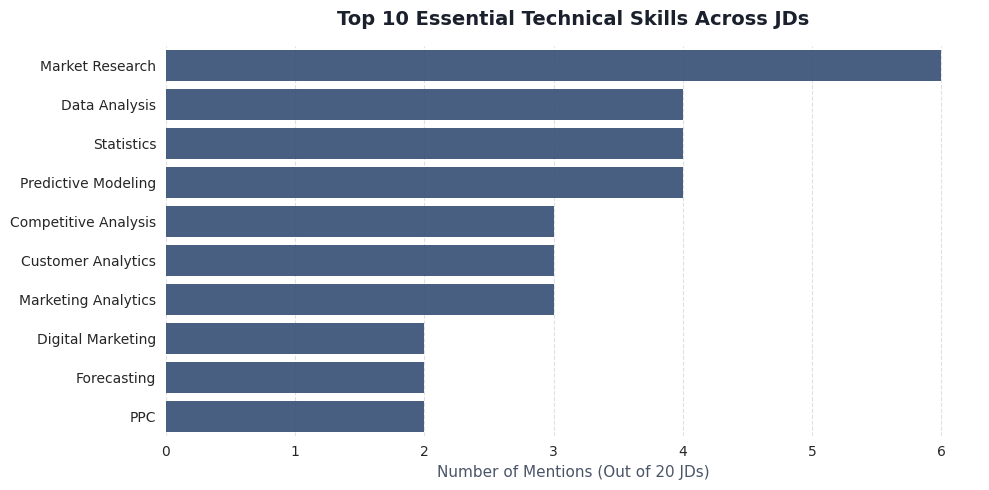

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean grid background style
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

# Initialize a dedicated figure for Technical Skills
plt.figure(figsize=(10, 5))

# Plotting the data
sns.barplot(
    data=tech_table.head(10),
    x='Mentions Count',
    y='Technical Skills',
    color='#2B4C7E',    # Elegant Deep Slate Blue
    edgecolor='none',
    alpha=0.9
)

# Styling details
plt.title('Top 10 Essential Technical Skills Across JDs', fontsize=14, fontweight='bold', color='#1A202C', pad=15)
plt.xlabel('Number of Mentions (Out of 20 JDs)', fontsize=11, color='#4A5568')
plt.ylabel('')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.grid(axis='y', visible=False)

# Clean up layout and display
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

## Step 7: Chart Generation — Soft Skills

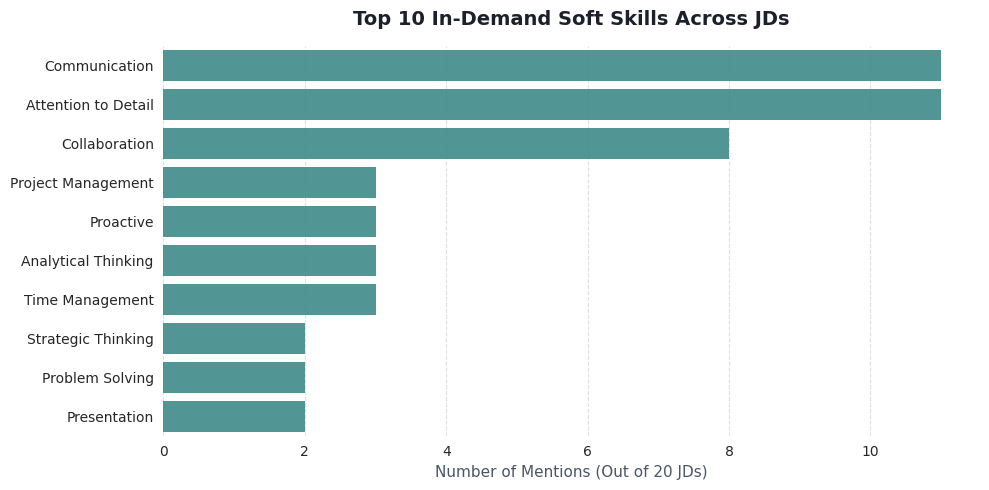

In [13]:
# Initialize a dedicated figure for Soft Skills
plt.figure(figsize=(10, 5))

# Plotting the data
sns.barplot(
    data=soft_table.head(10),
    x='Mentions Count',
    y='Soft Skills',
    color='#319795',    # Elegant Deep Teal
    edgecolor='none',
    alpha=0.9
)

# Styling details
plt.title('Top 10 In-Demand Soft Skills Across JDs', fontsize=14, fontweight='bold', color='#1A202C', pad=15)
plt.xlabel('Number of Mentions (Out of 20 JDs)', fontsize=11, color='#4A5568')
plt.ylabel('')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.grid(axis='y', visible=False)

# Clean up layout and display
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

## Step 8: Chart Generation — Tools & Softwares

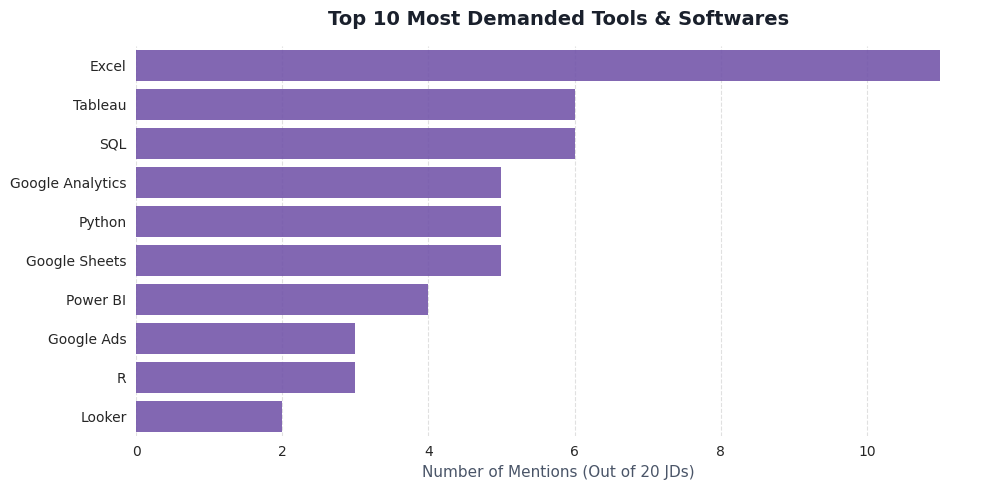

In [15]:
# Initialize a dedicated figure for Tools & Softwares
plt.figure(figsize=(10, 5))

# Plotting the data
sns.barplot(
    data=tools_table.head(10),
    x='Mentions Count',
    y='Tools',
    color='#7048B8',    # Premium Royal Amethyst
    edgecolor='none',
    alpha=0.9
)

# Styling details
plt.title('Top 10 Most Demanded Tools & Softwares', fontsize=14, fontweight='bold', color='#1A202C', pad=15)
plt.xlabel('Number of Mentions (Out of 20 JDs)', fontsize=11, color='#4A5568')
plt.ylabel('')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.grid(axis='y', visible=False)

# Clean up layout and display
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

### Step 9: Combined Master Skills & Tools Frequency Table

---



In [16]:
import pandas as pd
from collections import Counter

# 1. Load your dataset
file_name = 'JD Analysis Table.csv'
df = pd.read_csv(file_name)

# 2. Helper function to count individual elements parsed by '|'
def get_counts(series):
    items = []
    for val in series.dropna():
        items.extend([item.strip() for item in str(val).split('|') if item.strip()])
    return Counter(items)

# 3. Aggregate item occurrences across categories
tech_counts = get_counts(df['Technical Skills'])
soft_counts = get_counts(df['Soft Skills'])
tools_counts = get_counts(df['Tools'])

# 4. Compile everything into a unified list
combined_data = []

for skill, count in tech_counts.items():
    combined_data.append({'Item Name': skill, 'Category': 'Technical Skill', 'Mentions Count': count})

for skill, count in soft_counts.items():
    combined_data.append({'Item Name': skill, 'Category': 'Soft Skill', 'Mentions Count': count})

for tool, count in tools_counts.items():
    combined_data.append({'Item Name': tool, 'Category': 'Tool / Software', 'Mentions Count': count})

# 5. Convert to DataFrame and sort from highest to lowest demand
master_frequency_df = pd.DataFrame(combined_data)
master_frequency_df['% of Total JDs'] = (master_frequency_df['Mentions Count'] / 20 * 100).map('{:,.1f}%'.format)
master_frequency_df = master_frequency_df.sort_values(by='Mentions Count', ascending=False).reset_index(drop=True)

# 6. Display the final master table with an elegant gradient map in Colab
print("--- COMBINED MASTER SKILLS & TOOLS FREQUENCY TABLE ---")
display(master_frequency_df.style.background_gradient(cmap='Blues', subset=['Mentions Count']))

--- COMBINED MASTER SKILLS & TOOLS FREQUENCY TABLE ---


,Item Name,Category,Mentions Count,% of Total JDs
0,Communication,Soft Skill,11,55.0%
1,Excel,Tool / Software,11,55.0%
2,Attention to Detail,Soft Skill,11,55.0%
3,Collaboration,Soft Skill,8,40.0%
4,Market Research,Technical Skill,6,30.0%
5,Tableau,Tool / Software,6,30.0%
6,SQL,Tool / Software,6,30.0%
7,Google Analytics,Tool / Software,5,25.0%
8,Python,Tool / Software,5,25.0%
9,Google Sheets,Tool / Software,5,25.0%


# Creating Dashboard / Visualization

## Step 1: Minimum Requirement — Top 10 Most Demanded Skills & Tools

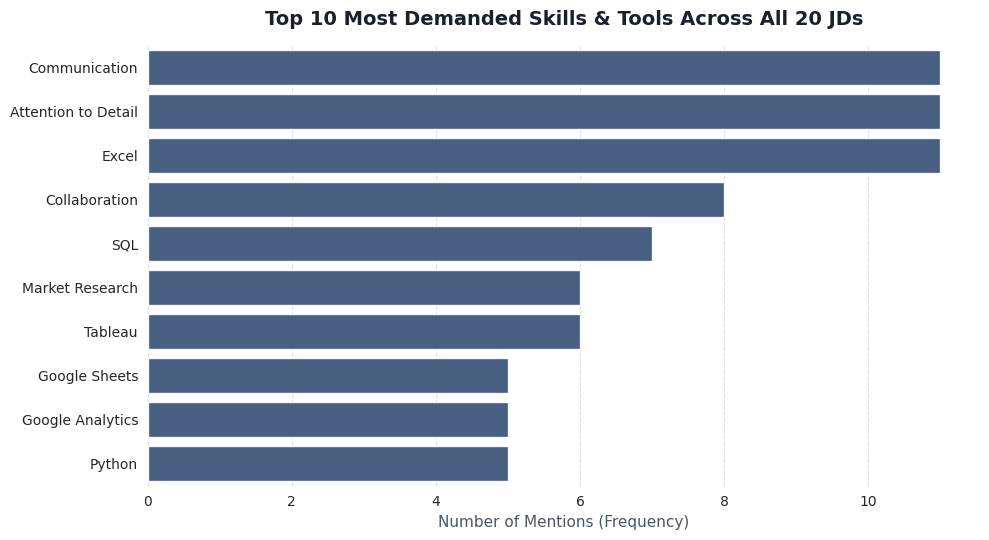

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Load the verified dataset
df = pd.read_csv('JD Analysis Table.csv')

# Parse and combine all items
all_items = []
for col in ['Technical Skills', 'Soft Skills', 'Tools']:
    for val in df[col].dropna():
        all_items.extend([item.strip() for item in str(val).split('|') if item.strip()])

# Create top 10 DataFrame
top_10_df = pd.DataFrame(Counter(all_items).most_common(10), columns=['Skill / Tool', 'Mentions Count'])

# Set plot style
sns.set_style("whitegrid")
plt.figure(figsize=(10, 5.5))

# Generate the bar chart
sns.barplot(data=top_10_df, x='Mentions Count', y='Skill / Tool', color='#2B4C7E', alpha=0.9)

# Formatting
plt.title('Top 10 Most Demanded Skills & Tools Across All 20 JDs', fontsize=14, fontweight='bold', color='#1A202C', pad=15)
plt.xlabel('Number of Mentions (Frequency)', fontsize=11, color='#4A5568')
plt.ylabel('')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.grid(axis='y', visible=False)

sns.despine(left=True, bottom=True)
plt.tight_layout()

# Save as separate required report file
plt.savefig('01_top_10_demanded_skills.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 2: Additional Chart 1 — Proportion of Technical vs. Soft Skills (Donut Chart)

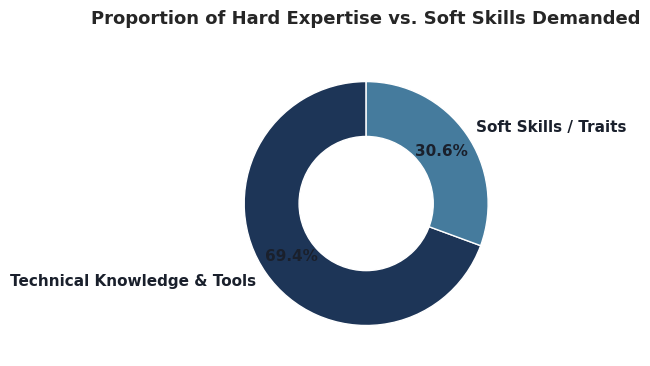

In [19]:
# Separate counts for Technical vs Soft attributes
tech_count = sum(len([i.strip() for i in str(val).split('|') if i.strip()]) for val in df['Technical Skills'].dropna())
tools_count = sum(len([i.strip() for i in str(val).split('|') if i.strip()]) for val in df['Tools'].dropna())
soft_count = sum(len([i.strip() for i in str(val).split('|') if i.strip()]) for val in df['Soft Skills'].dropna())

categories = ['Technical Knowledge & Tools', 'Soft Skills / Traits']
proportions = [tech_count + tools_count, soft_count]
colors = ['#1D3557', '#457B9D']  # Elegant Blue & Muted Teal

# Create Donut Chart
plt.figure(figsize=(6, 6))
plt.pie(proportions, labels=categories, colors=colors, autopct='%1.1f%%', startangle=90,
        pctdistance=0.75, textprops={'fontsize': 11, 'fontweight': 'bold', 'color': '#1A202C'})

# Draw central circle to turn Pie into Donut
centre_circle = plt.Circle((0,0), 0.55, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Proportion of Hard Expertise vs. Soft Skills Demanded', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()

plt.savefig('02_technical_vs_soft_proportion.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 3: Additional Chart 2 — Regional Comparison (Pakistani vs. Foreign Companies)

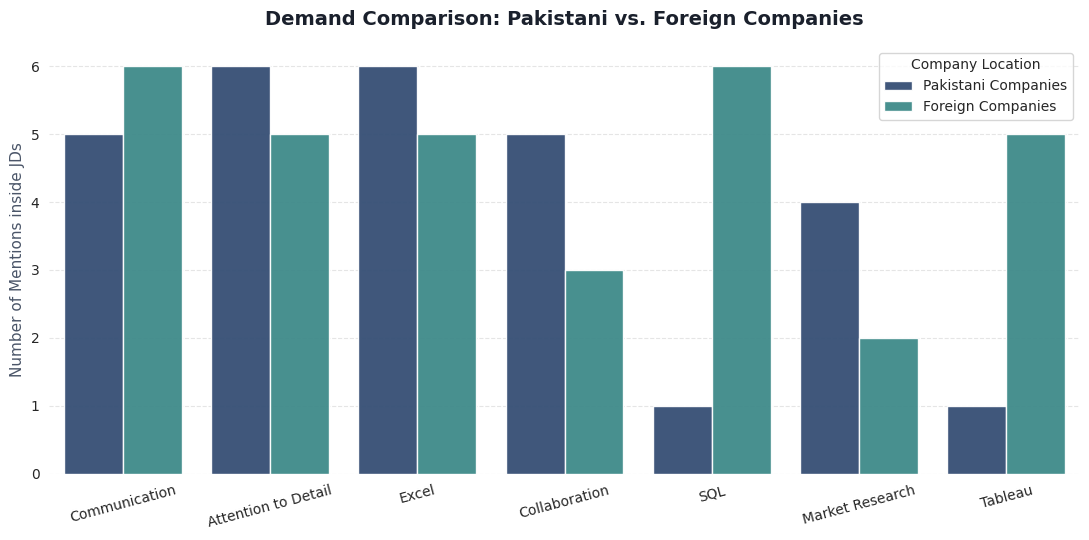

In [21]:
# Create a local/foreign grouping feature
df['Market Type'] = df['Country'].apply(lambda x: 'Pakistani Companies' if x == 'Pakistan' else 'Foreign Companies')

def count_market_items(dataframe, market_name):
    items = []
    sub_df = dataframe[dataframe['Market Type'] == market_name]
    for col in ['Technical Skills', 'Soft Skills', 'Tools']:
        for val in sub_df[col].dropna():
            items.extend([item.strip() for item in str(val).split('|') if item.strip()])
    return Counter(items)

pak_counts = count_market_items(df, 'Pakistani Companies')
for_counts = count_market_items(df, 'Foreign Companies')

# Pick top 7 benchmarks to compare
top_benchmarks = [item for item, _ in Counter(all_items).most_common(7)]

comp_records = []
for item in top_benchmarks:
    comp_records.append({'Skill / Tool': item, 'Market': 'Pakistani Companies', 'Mentions': pak_counts.get(item, 0)})
    comp_records.append({'Skill / Tool': item, 'Market': 'Foreign Companies', 'Mentions': for_counts.get(item, 0)})

comp_df = pd.DataFrame(comp_records)

# Plot Side-by-Side Comparison Group Chart
plt.figure(figsize=(11, 5.5))
sns.barplot(data=comp_df, x='Skill / Tool', y='Mentions', hue='Market', palette=['#2B4C7E', '#319795'], alpha=0.95)

plt.title('Demand Comparison: Pakistani vs. Foreign Companies', fontsize=14, fontweight='bold', color='#1A202C', pad=15)
plt.xlabel('', fontsize=11)
plt.ylabel('Number of Mentions inside JDs', fontsize=11, color='#4A5568')
plt.legend(title='Company Location', frameon=True)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.grid(axis='x', visible=False)

sns.despine(left=True, bottom=True)
plt.tight_layout()

plt.savefig('03_regional_market_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 4: Additional Chart 3 — Professional Word Cloud Visual

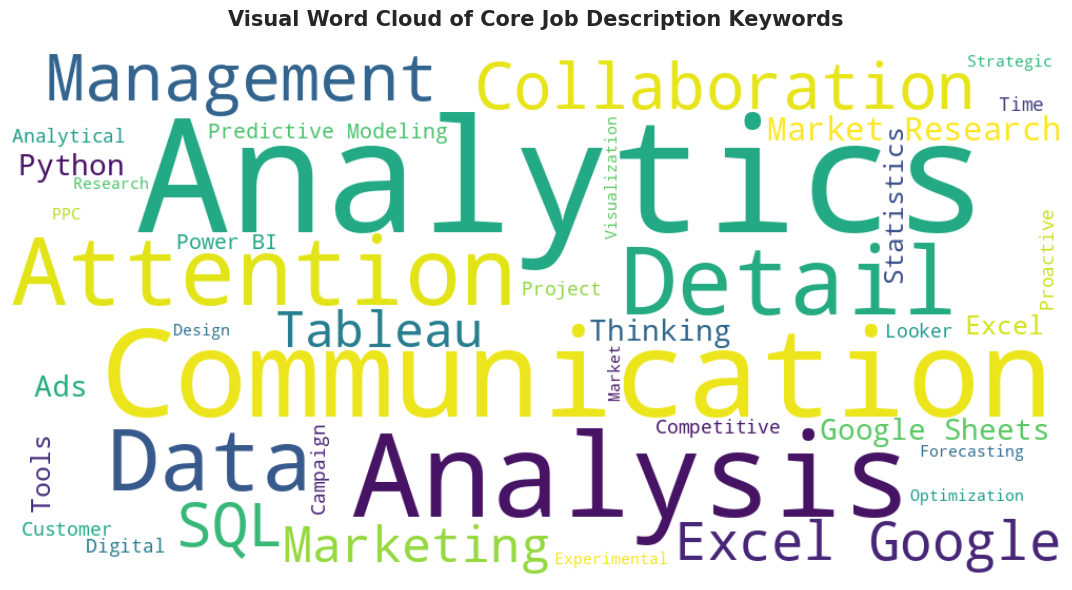

In [22]:
from wordcloud import WordCloud

# Combine text entries into a single string corpus
text_corpus = " ".join(all_items)

# Configure the WordCloud layout using a clean, dark-to-light theme mapping
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    colormap='viridis',
    max_words=40,
    prefer_horizontal=0.85
).generate(text_corpus)

# Plot WordCloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Hide processing axes scales
plt.title('Visual Word Cloud of Core Job Description Keywords', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()

plt.savefig('04_jd_keyword_wordcloud.png', dpi=300, bbox_inches='tight')
plt.show()

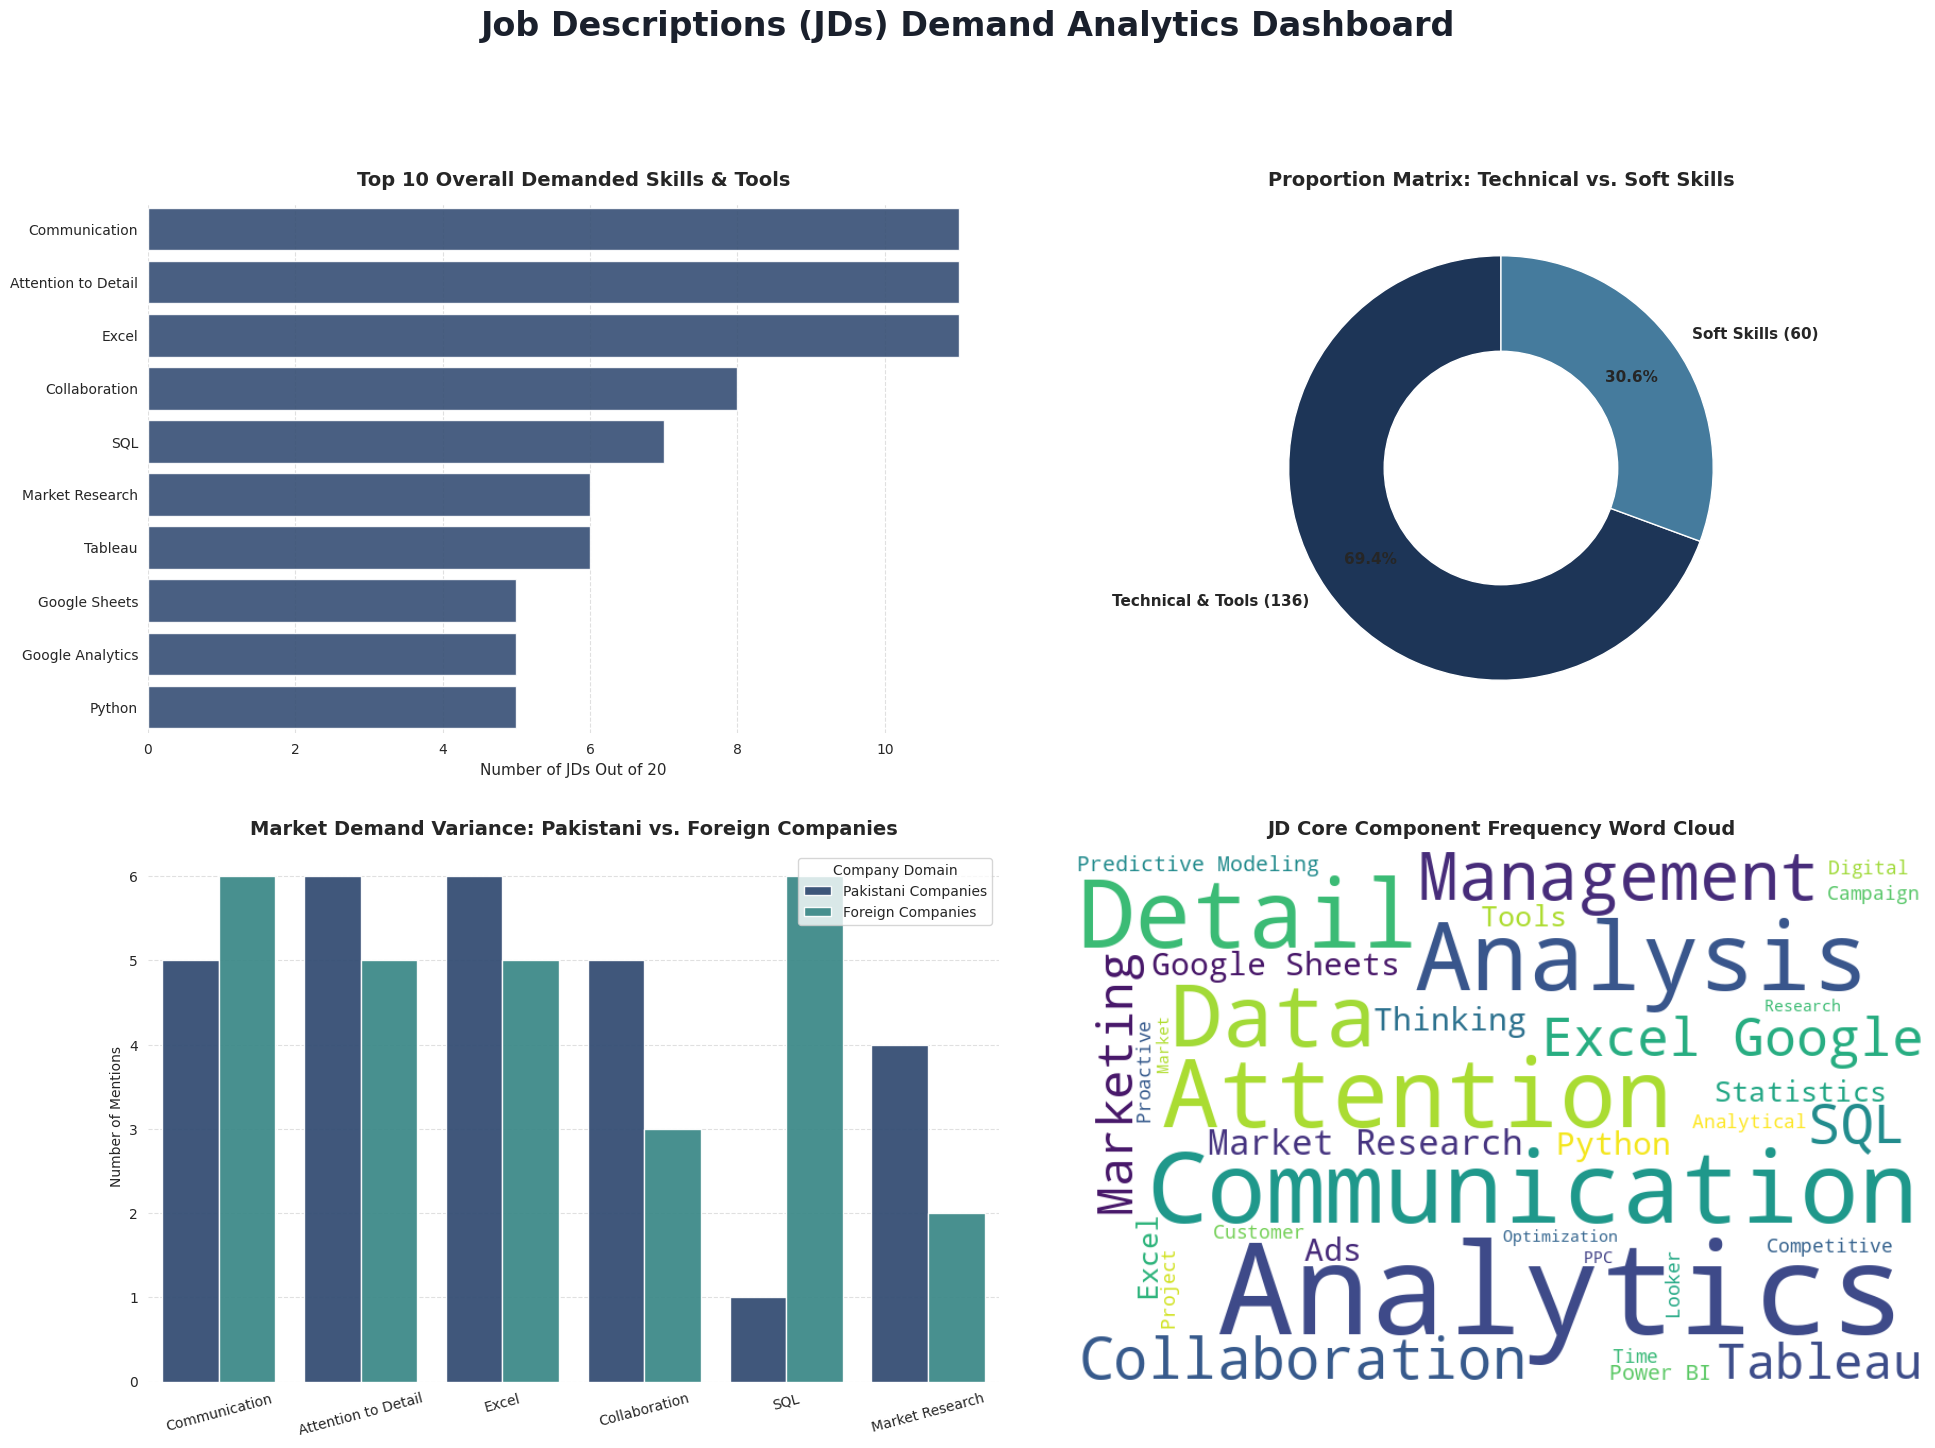

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

# ==========================================
# 1. LOAD DATA & INITIALIZE DEMAND METRICS
# ==========================================
file_name = 'JD Analysis Table.csv'
df = pd.read_csv(file_name)

# Parse item tokens across columns
all_items = []
tech_items = []
soft_items = []
tools_items = []

for val in df['Technical Skills'].dropna():
    items = [i.strip() for i in str(val).split('|') if i.strip()]
    all_items.extend(items)
    tech_items.extend(items)

for val in df['Soft Skills'].dropna():
    items = [i.strip() for i in str(val).split('|') if i.strip()]
    all_items.extend(items)
    soft_items.extend(items)

for val in df['Tools'].dropna():
    items = [i.strip() for i in str(val).split('|') if i.strip()]
    all_items.extend(items)
    tools_items.extend(items)

# Top 10 Master Data Frame
top_10_df = pd.DataFrame(Counter(all_items).most_common(10), columns=['Skill / Tool', 'Count'])

# Regional Comparison Processing
df['Market Type'] = df['Country'].apply(lambda x: 'Pakistani Companies' if x == 'Pakistan' else 'Foreign Companies')

def count_market_items(dataframe, market_name):
    items = []
    sub_df = dataframe[dataframe['Market Type'] == market_name]
    for col in ['Technical Skills', 'Soft Skills', 'Tools']:
        for val in sub_df[col].dropna():
            items.extend([i.strip() for i in str(val).split('|') if i.strip()])
    return Counter(items)

pak_counts = count_market_items(df, 'Pakistani Companies')
for_counts = count_market_items(df, 'Foreign Companies')

top_benchmarks = [item for item, _ in Counter(all_items).most_common(6)]
comp_records = []
for item in top_benchmarks:
    comp_records.append({'Skill / Tool': item, 'Market': 'Pakistani Companies', 'Mentions': pak_counts.get(item, 0)})
    comp_records.append({'Skill / Tool': item, 'Market': 'Foreign Companies', 'Mentions': for_counts.get(item, 0)})
comp_df = pd.DataFrame(comp_records)

# ==========================================
# 2. CONSTRUCT UNIFIED EXECUTIVE DASHBOARD
# ==========================================
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

# Initialize a clean grid structure (2 rows x 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
fig.suptitle('Job Descriptions (JDs) Demand Analytics Dashboard', fontsize=24, fontweight='bold', color='#1A202C', y=0.98)

# --- PANEL A: Top 10 Demanded Skills & Tools (Top Left) ---
sns.barplot(data=top_10_df, x='Count', y='Skill / Tool', color='#2B4C7E', ax=axes[0, 0], alpha=0.9)
axes[0, 0].set_title('Top 10 Overall Demanded Skills & Tools', fontsize=14, fontweight='bold', pad=12)
axes[0, 0].set_xlabel('Number of JDs Out of 20', fontsize=11)
axes[0, 0].set_ylabel('')
axes[0, 0].grid(axis='x', linestyle='--', alpha=0.6)
axes[0, 0].grid(axis='y', visible=False)

# --- PANEL B: Technical vs. Soft Skills Donut (Top Right) ---
tech_total = len(tech_items) + len(tools_items)
soft_total = len(soft_items)
proportions = [tech_total, soft_total]
categories = [f'Technical & Tools ({tech_total})', f'Soft Skills ({soft_total})']

axes[0, 1].pie(proportions, labels=categories, colors=['#1D3557', '#457B9D'], autopct='%1.1f%%', startangle=90, pctdistance=0.75,
               textprops={'fontsize': 11, 'fontweight': 'bold'})
centre_circle = plt.Circle((0, 0), 0.55, fc='white')
axes[0, 1].add_artist(centre_circle)
axes[0, 1].set_title('Proportion Matrix: Technical vs. Soft Skills', fontsize=14, fontweight='bold', pad=12)

# --- PANEL C: Market Breakdown Comparison (Bottom Left) ---
sns.barplot(data=comp_df, x='Skill / Tool', y='Mentions', hue='Market', palette=['#2B4C7E', '#319795'], ax=axes[1, 0], alpha=0.95)
axes[1, 0].set_title('Market Demand Variance: Pakistani vs. Foreign Companies', fontsize=14, fontweight='bold', pad=12)
axes[1, 0].set_xlabel('')
axes[1, 0].set_ylabel('Number of Mentions')
axes[1, 0].legend(title='Company Domain')
axes[1, 0].tick_params(axis='x', rotation=15)
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.6)
axes[1, 0].grid(axis='x', visible=False)

# --- PANEL D: Dense Keyword Word Cloud (Bottom Right) ---
wordcloud = WordCloud(
    width=800,
    height=500,
    background_color='white',
    colormap='viridis',
    max_words=35,
    prefer_horizontal=0.85
).generate(" ".join(all_items))

axes[1, 1].imshow(wordcloud, interpolation='bilinear')
axes[1, 1].axis('off')
axes[1, 1].set_title('JD Core Component Frequency Word Cloud', fontsize=14, fontweight='bold', pad=12)

# ==========================================
# 3. LAYOUT CLEANUP & FILE EXPORT
# ==========================================
sns.despine(left=True, bottom=True)
plt.tight_layout(rect=[0, 0, 1, 0.95], pad=3.0)

# Save the consolidated canvas dashboard as a single file
plt.savefig('combined_market_analytics_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()


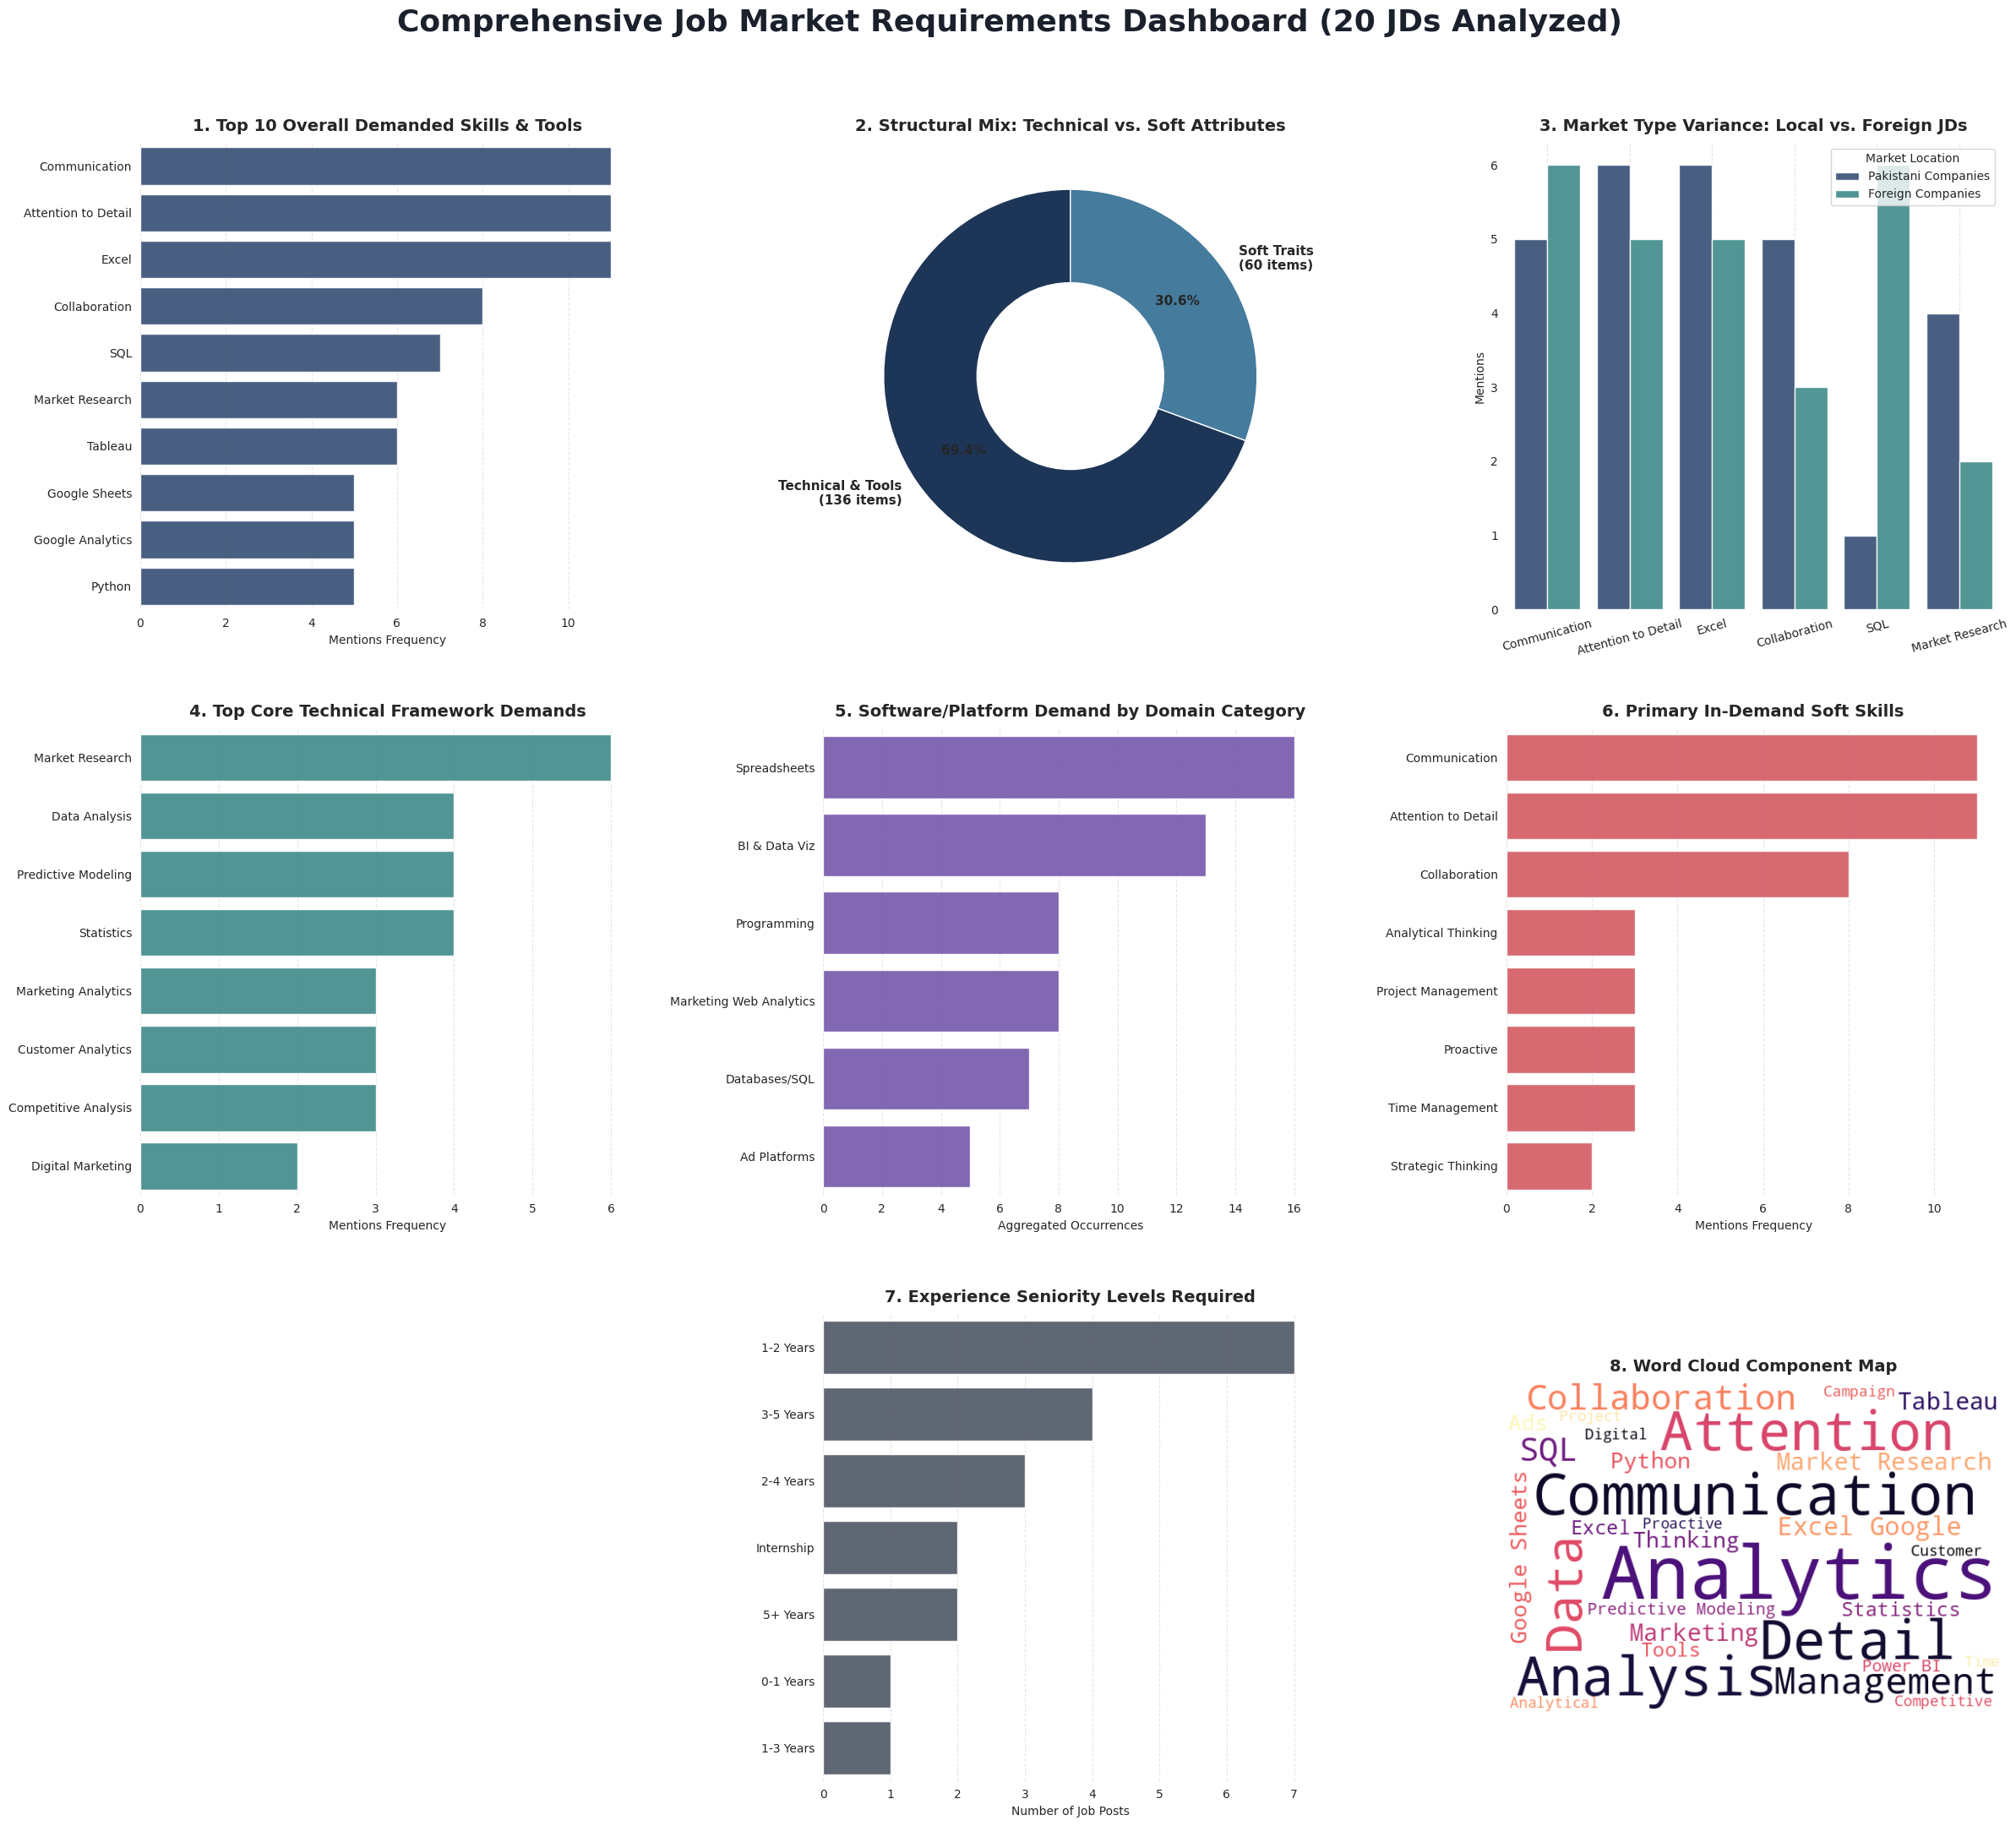

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

# ==========================================
# 1. LOAD DATA & INITIALIZE METRICS
# ==========================================
file_name = 'JD Analysis Table.csv'
df = pd.read_csv(file_name)

# Parse data tokens across categories
all_items = []
tech_items = []
soft_items = []
tools_items = []

for val in df['Technical Skills'].dropna():
    items = [i.strip() for i in str(val).split('|') if i.strip()]
    all_items.extend(items)
    tech_items.extend(items)

for val in df['Soft Skills'].dropna():
    items = [i.strip() for i in str(val).split('|') if i.strip()]
    all_items.extend(items)
    soft_items.extend(items)

for val in df['Tools'].dropna():
    items = [i.strip() for i in str(val).split('|') if i.strip()]
    all_items.extend(items)
    tools_items.extend(items)

# Generate category counts for specific data views
top_10_df = pd.DataFrame(Counter(all_items).most_common(10), columns=['Skill / Tool', 'Count'])
tech_counts_df = pd.DataFrame(Counter(tech_items).most_common(8), columns=['Technical Skill', 'Count'])
soft_counts_df = pd.DataFrame(Counter(soft_items).most_common(8), columns=['Soft Skill', 'Count'])

# Regional Parsing
df['Market Type'] = df['Country'].apply(lambda x: 'Pakistani Companies' if x == 'Pakistan' else 'Foreign Companies')
def count_market_items(dataframe, market_name):
    items = []
    sub_df = dataframe[dataframe['Market Type'] == market_name]
    for col in ['Technical Skills', 'Soft Skills', 'Tools']:
        for val in sub_df[col].dropna():
            items.extend([i.strip() for i in str(val).split('|') if i.strip()])
    return Counter(items)

pak_counts = count_market_items(df, 'Pakistani Companies')
for_counts = count_market_items(df, 'Foreign Companies')
top_benchmarks = [item for item, _ in Counter(all_items).most_common(6)]
comp_records = []
for item in top_benchmarks:
    comp_records.append({'Skill / Tool': item, 'Market': 'Pakistani Companies', 'Mentions': pak_counts.get(item, 0)})
    comp_records.append({'Skill / Tool': item, 'Market': 'Foreign Companies', 'Mentions': for_counts.get(item, 0)})
comp_df = pd.DataFrame(comp_records)

# Tool Categorization Setup
tool_categories = {
    'Spreadsheets': tools_items.count('Excel') + tools_items.count('Google Sheets'),
    'BI & Data Viz': tools_items.count('Tableau') + tools_items.count('Power BI') + tools_items.count('Looker') + tools_items.count('Looker Studio'),
    'Databases/SQL': tools_items.count('SQL') + tools_items.count('BigQuery'),
    'Programming': tools_items.count('Python') + tools_items.count('R'),
    'Marketing Web Analytics': tools_items.count('Google Analytics') + tools_items.count('Adobe Analytics') + tools_items.count('Amplitude'),
    'Ad Platforms': tools_items.count('Google Ads') + tools_items.count('Meta Ads')
}
tool_cat_df = pd.DataFrame(list(tool_categories.items()), columns=['Tool Category', 'Count']).sort_values(by='Count', ascending=False)

# Experience levels distribution
exp_df = df['Experience'].value_counts().reset_index()
exp_df.columns = ['Experience Level', 'Count']

# ==========================================
# 2. CONSTRUCT GRID DASHBOARD (7 VISUALS)
# ==========================================
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

# Initialize a professional 3x3 layout (leaving room for elegant spacing)
fig, axes = plt.subplots(3, 3, figsize=(24, 22))
fig.suptitle('Comprehensive Job Market Requirements Dashboard (20 JDs Analyzed)', fontsize=26, fontweight='bold', color='#1A202C', y=0.98)

# Brand Color Archetypes
c_blue = '#2B4C7E'
c_teal = '#319795'
c_purple = '#7048B8'
c_slate = '#4A5568'

# --- CHART 1: Top 10 Combined Demand (Row 1, Left) ---
sns.barplot(data=top_10_df, x='Count', y='Skill / Tool', color=c_blue, ax=axes[0, 0], alpha=0.9)
axes[0, 0].set_title('1. Top 10 Overall Demanded Skills & Tools', fontsize=14, fontweight='bold', pad=10)
axes[0, 0].set_xlabel('Mentions Frequency')
axes[0, 0].set_ylabel('')

# --- CHART 2: Hard vs. Soft Skills Proportions (Row 1, Center) ---
tech_total = len(tech_items) + len(tools_items)
soft_total = len(soft_items)
axes[0, 1].pie([tech_total, soft_total], labels=[f'Technical & Tools\n({tech_total} items)', f'Soft Traits\n({soft_total} items)'],
               colors=['#1D3557', '#457B9D'], autopct='%1.1f%%', startangle=90, pctdistance=0.7, textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[0, 1].add_artist(plt.Circle((0, 0), 0.50, fc='white'))
axes[0, 1].set_title('2. Structural Mix: Technical vs. Soft Attributes', fontsize=14, fontweight='bold', pad=10)

# --- CHART 3: Regional Domain Variance (Row 1, Right) ---
sns.barplot(data=comp_df, x='Skill / Tool', y='Mentions', hue='Market', palette=[c_blue, c_teal], ax=axes[0, 2], alpha=0.9)
axes[0, 2].set_title('3. Market Type Variance: Local vs. Foreign JDs', fontsize=14, fontweight='bold', pad=10)
axes[0, 2].set_xlabel('')
axes[0, 2].set_ylabel('Mentions')
axes[0, 2].tick_params(axis='x', rotation=15)
axes[0, 2].legend(title='Market Location')

# --- CHART 4: Top Technical Skills Only (Row 2, Left) ---
sns.barplot(data=tech_counts_df, x='Count', y='Technical Skill', color=c_teal, ax=axes[1, 0], alpha=0.9)
axes[1, 0].set_title('4. Top Core Technical Framework Demands', fontsize=14, fontweight='bold', pad=10)
axes[1, 0].set_xlabel('Mentions Frequency')
axes[1, 0].set_ylabel('')

# --- CHART 5: Software & Tool Classification (Row 2, Center) ---
sns.barplot(data=tool_cat_df, x='Count', y='Tool Category', color=c_purple, ax=axes[1, 1], alpha=0.9)
axes[1, 1].set_title('5. Software/Platform Demand by Domain Category', fontsize=14, fontweight='bold', pad=10)
axes[1, 1].set_xlabel('Aggregated Occurrences')
axes[1, 1].set_ylabel('')

# --- CHART 6: Top Behavioral Soft Traits (Row 2, Right) ---
sns.barplot(data=soft_counts_df, x='Count', y='Soft Skill', color='#E63946', ax=axes[1, 2], alpha=0.85)
axes[1, 2].set_title('6. Primary In-Demand Soft Skills', fontsize=14, fontweight='bold', pad=10)
axes[1, 2].set_xlabel('Mentions Frequency')
axes[1, 2].set_ylabel('')

# --- CHART 7: Experience Level Milestones (Row 3, Center) ---
sns.barplot(data=exp_df, x='Count', y='Experience Level', color=c_slate, ax=axes[2, 1], alpha=0.9)
axes[2, 1].set_title('7. Experience Seniority Levels Required', fontsize=14, fontweight='bold', pad=10)
axes[2, 1].set_xlabel('Number of Job Posts')
axes[2, 1].set_ylabel('')

# --- CLEAN UP BLANK SPACES IN THE GRID GRID OVERLAYS ---
# We use a 3x3 layout to gracefully fit 7 charts while preserving clear readability
axes[2, 0].axis('off') # Hide bottom-left placeholder
# Generate a clean keyword word cloud inside the final bottom-right block
wordcloud = WordCloud(width=600, height=400, background_color='white', colormap='magma', max_words=30).generate(" ".join(all_items))
axes[2, 2].imshow(wordcloud, interpolation='bilinear')
axes[2, 2].axis('off')
axes[2, 2].set_title('8. Word Cloud Component Map', fontsize=14, fontweight='bold', pad=10)

# General grid cleanups
for row in range(3):
    for col in range(3):
        ax = axes[row, col]
        if ax.axison: # Only edit active chart axes
            ax.xaxis.grid(True, linestyle='--', alpha=0.5)
            ax.yaxis.grid(False)

sns.despine(left=True, bottom=True)
plt.tight_layout(rect=[0, 0, 1, 0.95], h_pad=4.0, w_pad=3.0)

# Save the final complex file canvas
plt.savefig('master_market_analytics_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

